### Volume / Row Count Check

In [ ]:
import os
import glob
import pandas as pd
# 1. Khai báo đường dẫn thư mục chứa dataset
folder_path = rf'D:\olist-customer-satisfaction-analysis\data\raw'

# 2. Lấy danh sách tất cả các file .csv trong thư mục
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

total_lines = 0

print(f"Đang đếm số dòng cho {len(csv_files)} files...\n")

for file in csv_files:
    # Mở file và đếm số dòng (dùng generator để không tốn RAM)
    with open(file, 'r', encoding='utf-8', errors='ignore') as f:
        # Trừ 1 để không tính dòng Header (tên cột)
        lines = sum(1 for _ in f) - 1 
        
    total_lines += lines
    print(f"{os.path.basename(file)}: {lines:,} dòng")

print("-" * 30)
print(f"=> Tổng cộng: {total_lines:,} dòng dữ liệu")

Đang đếm số dòng cho 9 files...

olist_customers_dataset.csv: 99,441 dòng
olist_geolocation_dataset.csv: 1,000,163 dòng
olist_orders_dataset.csv: 99,441 dòng
olist_order_items_dataset.csv: 112,650 dòng
olist_order_payments_dataset.csv: 103,886 dòng
olist_order_reviews_dataset.csv: 104,719 dòng
olist_products_dataset.csv: 32,951 dòng
olist_sellers_dataset.csv: 3,095 dòng
product_category_name_translation.csv: 71 dòng
------------------------------
=> Tổng cộng: 1,556,417 dòng dữ liệu


Nhận xét: Tất cả các table đều được import data đầy đủ. Riêng olist_order_reviews có sự khác biệt (104,719/99224). Nghi ngờ là do nội dung review có chứa xuống dòng

In [ ]:
path = r'D:\olist-customer-satisfaction-analysis\data\raw\olist_order_reviews_dataset.csv'

# Đọc không chia chunk, dùng python engine, bắt lỗi rõ ràng
df_full = pd.read_csv(
    path, 
    engine='python', 
    on_bad_lines='warn',   # sẽ in ra dòng nào bị lỗi parse
    encoding='utf-8'
)

print(f"Tổng số dòng đọc được: {len(df_full)}")

# Đếm số dòng thực tế trong file CSV gốc (kể cả header)
with open(path, 'r', encoding='utf-8', errors='replace') as f:
    raw_line_count = sum(1 for _ in f)
print(f"Số dòng raw trong file (ước lượng, có thể lệch do multiline field): {raw_line_count - 1}")

Tổng số dòng đọc được: 99224
Số dòng raw trong file (ước lượng, có thể lệch do multiline field): 104719


### Logic Check

In [4]:
import pandas as pd
import numpy as np
import glob
import os

# 1. Đường dẫn thư mục chứa các file dữ liệu
folder_path = '../data/raw/'

# Tìm tất cả các file .csv trong thư mục
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

print(f"Đang quét {len(csv_files)} file CSV...\n")
print("=" * 60)

# Khởi tạo một list để lưu kết quả của từng bảng
all_results = []

# 2. Vòng lặp duyệt qua từng file
for file in csv_files:
    # Lấy tên file để in ra cho đẹp
    table_name = os.path.basename(file).replace('_dataset.csv', '').replace('.csv', '')
    
    # Đọc file (có thể dùng chunksize nếu máy yếu, nhưng ở đây đọc nhanh để check info)
    df = pd.read_csv(file)
    
    # Chỉ chọn cột số
    numeric_df = df.select_dtypes(include=[np.number])
    
    # Bỏ qua các cột chứa 'id' hoặc 'zip_code' (mã bưu điện tuy là số nhưng tính min/max vô nghĩa)
    cols_to_check = [col for col in numeric_df.columns if not (col.lower().endswith('id') or 'zip_code' in col.lower())]
    
    if not cols_to_check:
        continue # Nếu bảng này không có cột số nào hợp lệ thì bỏ qua
        
    # 3. Tính toán Min/Max
    for col in cols_to_check:
        min_val = df[col].min()
        max_val = df[col].max()
        
        # Đưa vào list tổng hợp
        all_results.append({
            'Tên Bảng': table_name,
            'Tên Cột': col,
            'Min': min_val,
            'Max': max_val
        })

# 4. Gộp toàn bộ kết quả thành 1 DataFrame duy nhất và in ra
if all_results:
    final_report = pd.DataFrame(all_results)
    
    # Format lại cho đẹp, chỉ in ra các thông số
    final_report.set_index(['Tên Bảng', 'Tên Cột'], inplace=True)
    
    print("BÁO CÁO KHOẢNG GIÁ TRỊ (RANGE CHECK) TOÀN BỘ DỰ ÁN")
    print("-" * 60)
    
    # Import display nếu dùng notebook
    from IPython.display import display
    display(final_report)
else:
    print("Không tìm thấy cột dữ liệu số nào phù hợp để kiểm tra.")

Đang quét 9 file CSV...

BÁO CÁO KHOẢNG GIÁ TRỊ (RANGE CHECK) TOÀN BỘ DỰ ÁN
------------------------------------------------------------


Min           Max
Tên Bảng             Tên Cột                                             
olist_geolocation    geolocation_lat             -36.605374     45.065933
                     geolocation_lng            -101.466766    121.105394
olist_order_items    price                         0.850000   6735.000000
                     freight_value                 0.000000    409.680000
olist_order_payments payment_sequential            1.000000     29.000000
                     payment_installments          0.000000     24.000000
                     payment_value                 0.000000  13664.080000
olist_order_reviews  review_score                  1.000000      5.000000
olist_products       product_name_lenght           5.000000     76.000000
                     product_description_lenght    4.000000   3992.000000
                     product_photos_qty            1.000000     20.000000
                     product_weight_g              0.000000  40425.000000
                     product_length_cm             7.000000    105.000000
                     product_height_cm             2.000000    105.000000
                     product_width_cm              6.000000    118.000000

### Missing Value Check per Table


In [4]:
from pathlib import Path
import pandas as pd
# Thư mục chứa các file CSV
data_dir = Path("../data/raw")  # Nếu notebook ở thư mục notebooks/
csv_files = sorted(data_dir.glob("*.csv"))

results = []

for csv_path in csv_files:
    # Đọc CSV theo từng chunk để giảm bộ nhớ sử dụng
    row_count = 0
    missing_counts = None

    for chunk in pd.read_csv(
        csv_path,
        chunksize=50_000,
        keep_default_na=True
    ):
        # Tính giá trị thiếu: NaN hoặc chuỗi rỗng
        missing_mask = chunk.isna() | chunk.astype("string").apply(
            lambda column: column.str.strip().eq("")
        )

        chunk_missing = missing_mask.sum()

        if missing_counts is None:
            missing_counts = chunk_missing
        else:
            missing_counts = missing_counts.add(chunk_missing, fill_value=0)

        row_count += len(chunk)

    # Thêm kết quả cho từng cột trong file
    for column_name, missing_count in missing_counts.items():
        results.append({
            "file_name": csv_path.name,
            "column_name": column_name,
            "missing_count": int(missing_count),
            "row_count": row_count,
            "missing_pct": round(missing_count / row_count * 100, 2)
            if row_count else 0
        })

# Tổng hợp và hiển thị
df_missing = pd.DataFrame(results)

pd.set_option("display.max_rows", None)
print(
    df_missing
    .sort_values(["file_name", "column_name"])
    .to_string(index=False)
)

                            file_name                   column_name  missing_count  row_count  missing_pct
          olist_customers_dataset.csv                 customer_city              0      99441         0.00
          olist_customers_dataset.csv                   customer_id              0      99441         0.00
          olist_customers_dataset.csv                customer_state              0      99441         0.00
          olist_customers_dataset.csv            customer_unique_id              0      99441         0.00
          olist_customers_dataset.csv      customer_zip_code_prefix              0      99441         0.00
        olist_geolocation_dataset.csv              geolocation_city              0    1000163         0.00
        olist_geolocation_dataset.csv               geolocation_lat              0    1000163         0.00
        olist_geolocation_dataset.csv               geolocation_lng              0    1000163         0.00
        olist_geolocation_dataset.csv

### Missing Values Check In Detail

##### *1. olist_orders: 160 missing values ở order_approved_at*

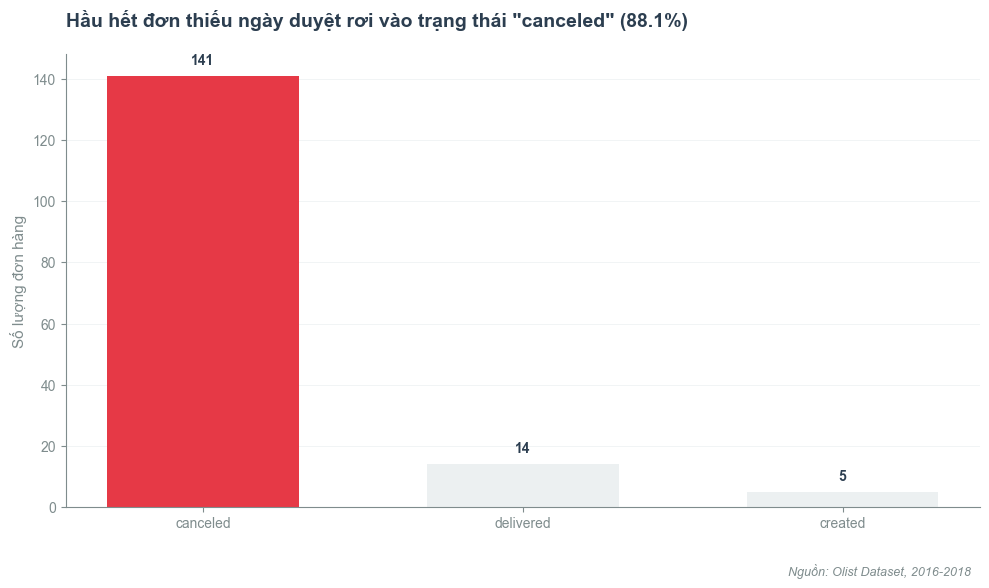

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# THIẾT LẬP STYLE THEO CHUẨN DA PROFESSIONAL
# ==========================================
COLOR_PRIMARY = '#2C3E50'
COLOR_ACCENT_POS = '#2E86AB'
COLOR_ACCENT_NEG = '#E63946'
COLOR_NEUTRAL = '#ECF0F1'
COLOR_TEXT_GRAY = "#8FA1A2"

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': COLOR_TEXT_GRAY,
    'axes.grid': True,
    'grid.color': COLOR_NEUTRAL,
    'grid.linewidth': 0.5,
    'axes.axisbelow': True,       
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ==========================================
# 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
orders_file_path = '../data/raw/olist_orders_dataset.csv'
df_orders = pd.read_csv(orders_file_path)

# Lọc các dòng thiếu order_approved_at và đếm số lượng theo order_status
missing_approved = df_orders[df_orders['order_approved_at'].isnull()]
status_counts = missing_approved['order_status'].value_counts()

# ==========================================
# 2. VẼ BIỂU ĐỒ (BAR CHART THAY VÌ PIE CHART)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Gán màu neutral cho tất cả các cột (Rule 5)
colors = [COLOR_NEUTRAL] * len(status_counts)
# Highlight cột cao nhất (rủi ro/bất thường nhất) bằng màu Accent Cảnh báo
if len(colors) > 0:
    colors[0] = COLOR_ACCENT_NEG 

# Vẽ Bar chart sắp xếp giảm dần tự nhiên từ value_counts() (Rule 3)
bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.6)

# Thêm Data label trực tiếp trên từng cột (Rule 5)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + (status_counts.max() * 0.02), 
                f'{int(yval):,}', ha='center', va='bottom', 
                fontsize=10, color=COLOR_PRIMARY, fontweight='bold')

# Tự động tính toán số liệu để viết Title dạng Insight (Rule 2)
if not status_counts.empty:
    top_status = status_counts.index[0]
    top_pct = (status_counts.values[0] / status_counts.sum()) * 100
    insight_title = f'Hầu hết đơn thiếu ngày duyệt rơi vào trạng thái "{top_status}" ({top_pct:.1f}%)'
else:
    insight_title = 'Không có đơn hàng nào bị thiếu ngày duyệt'

ax.set_title(insight_title, fontsize=14, fontweight='bold', color=COLOR_PRIMARY, loc='left', pad=20)

# Tùy chỉnh trục và label (Rule 3 & Rule 5)
ax.set_ylabel('Số lượng đơn hàng', color=COLOR_TEXT_GRAY, fontsize=11)
ax.tick_params(axis='x', colors=COLOR_TEXT_GRAY, labelsize=10)
ax.tick_params(axis='y', colors=COLOR_TEXT_GRAY, labelsize=10)

# Giữ gridline ngang, bỏ gridline dọc (lưu ý: axis='y' trong matplotlib vẽ đường ngang)
ax.grid(axis='y', color=COLOR_NEUTRAL, linestyle='-') 
ax.grid(axis='x', visible=False) 

# Ghi nguồn dữ liệu ở góc dưới phải (Rule 5)
ax.text(0.99, -0.15, 'Nguồn: Olist Dataset, 2016-2018', transform=ax.transAxes,
        ha='right', fontsize=9, color=COLOR_TEXT_GRAY, style='italic')

plt.tight_layout()
plt.show()

##### ==> Vì hầu hết các đơn hàng thiếu ngày duyệt đều rơi vào trạng thái "cancelled" nên đang có xu hướng tìm hiểu thêm về pattern của nó. Đặc điểm chung của những đơn này là gì? (MNAR)

* Nhìn từ biểu đồ prompt từ Excel thì nhận thấy rằng, các đơn hàng bị thiếu giá trị ở cột order_approved_date được đặt mua nhiều nhất vào các khoảng cố định như sau: 7/2018 - 9/2018, 1/2017 - 10/2017, 10/2016

* Một điều nữa được quan sát chính là trong 14 đơn hàng được giao tận nơi thì có đầy đủ thông tin về ngày giao cho đơn vị vận chuyển và giao cho khách trong khi 2 status còn lại thì hoàn toàn thiếu hai cột này

##### *2. olist_orders: 1783 missing values ở order_delivered_carrier_date*

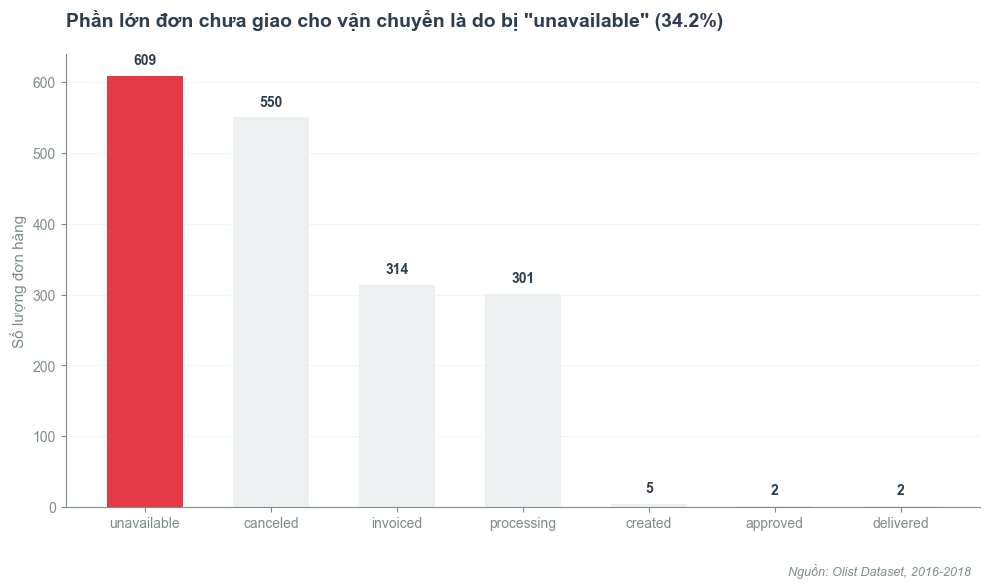

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# THIẾT LẬP STYLE THEO CHUẨN DA PROFESSIONAL
# ==========================================
COLOR_PRIMARY = '#2C3E50'
COLOR_ACCENT_POS = '#2E86AB'
COLOR_ACCENT_NEG = '#E63946'
COLOR_NEUTRAL = '#ECF0F1'
COLOR_TEXT_GRAY = '#7F8C8D'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': COLOR_TEXT_GRAY,
    'axes.grid': True,
    'grid.color': COLOR_NEUTRAL,
    'grid.linewidth': 0.5,
    'axes.axisbelow': True,       
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ==========================================
# 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
orders_file_path = '../data/raw/olist_orders_dataset.csv'
df_orders = pd.read_csv(orders_file_path)

# Lọc các dòng thiếu order_delivered_carrier_date
missing_carrier = df_orders[df_orders['order_delivered_carrier_date'].isnull()]
status_counts = missing_carrier['order_status'].value_counts()

# ==========================================
# 2. VẼ BIỂU ĐỒ BAR CHART
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Gán màu Neutral cho tất cả (Rule 5)
colors = [COLOR_NEUTRAL] * len(status_counts)

# Highlight nhóm lớn nhất. 
# Việc đơn hàng kẹt lại không giao được thường là rủi ro (hủy/hết hàng), dùng Accent Cảnh báo.
if len(colors) > 0:
    colors[0] = COLOR_ACCENT_NEG 

# Trục X là chuỗi chữ, dùng Vertical Bar Chart
bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.6)

# Thêm Data label (Rule 5)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + (status_counts.max() * 0.02), 
                f'{int(yval):,}', ha='center', va='bottom', 
                fontsize=10, color=COLOR_PRIMARY, fontweight='bold')

# Tự động tạo Insight Title (Rule 2)
if not status_counts.empty:
    top_status = status_counts.index[0]
    top_pct = (status_counts.values[0] / status_counts.sum()) * 100
    insight_title = f'Phần lớn đơn chưa giao cho vận chuyển là do bị "{top_status}" ({top_pct:.1f}%)'
else:
    insight_title = 'Không có đơn hàng nào bị thiếu ngày giao cho vận chuyển'

ax.set_title(insight_title, fontsize=14, fontweight='bold', color=COLOR_PRIMARY, loc='left', pad=20)

# Tùy chỉnh trục
ax.set_ylabel('Số lượng đơn hàng', color=COLOR_TEXT_GRAY, fontsize=11)
ax.tick_params(axis='x', colors=COLOR_TEXT_GRAY, labelsize=10)
ax.tick_params(axis='y', colors=COLOR_TEXT_GRAY, labelsize=10)

# Chỉ giữ gridline ngang (Rule 3)
ax.grid(axis='y', color=COLOR_NEUTRAL, linestyle='-') 
ax.grid(axis='x', visible=False) 

# Nguồn dữ liệu (Rule 5)
ax.text(0.99, -0.15, 'Nguồn: Olist Dataset, 2016-2018', transform=ax.transAxes,
        ha='right', fontsize=9, color=COLOR_TEXT_GRAY, style='italic')

plt.tight_layout()
plt.show()

##### ==> Phần lớn các đơn hàng không được trao đến đơn vị vận chuyển đều ở trạng thái không có sẵn hoặc bị hủy. Nên kiểm tra lại trước khi ra quyết định

* Các giá trị ngày giao đến đơn vị vận chuyển không hề có năm 2017. Và hầu hết tập trung tại 1/2018 - 3/2018 và 10/2016

##### *3. olist_orders: 2965 giá trị missing ở cột order_delivered_customer_date*

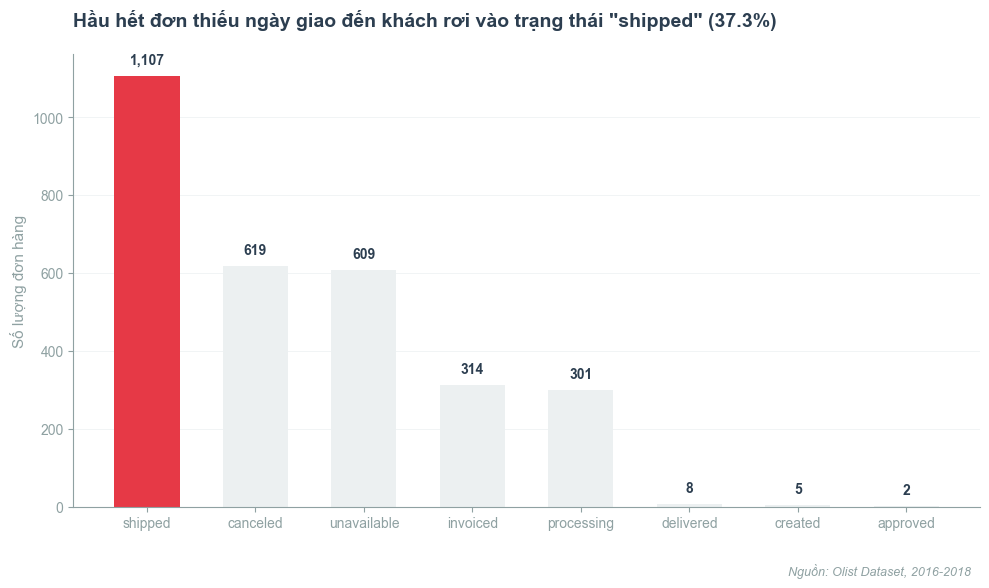

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# THIẾT LẬP STYLE THEO CHUẨN DA PROFESSIONAL
# ==========================================
COLOR_PRIMARY = '#2C3E50'
COLOR_ACCENT_POS = '#2E86AB'
COLOR_ACCENT_NEG = '#E63946'
COLOR_NEUTRAL = '#ECF0F1'
COLOR_TEXT_GRAY = "#8FA1A2"

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': COLOR_TEXT_GRAY,
    'axes.grid': True,
    'grid.color': COLOR_NEUTRAL,
    'grid.linewidth': 0.5,
    'axes.axisbelow': True,       
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ==========================================
# 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
orders_file_path = '../data/raw/olist_orders_dataset.csv'
df_orders = pd.read_csv(orders_file_path)

# Lọc các dòng thiếu order_delivered_customer_date và đếm số lượng theo order_status
missing_delivered = df_orders[df_orders['order_delivered_customer_date'].isnull()]
status_counts = missing_delivered['order_status'].value_counts()

# ==========================================
# 2. VẼ BIỂU ĐỒ (BAR CHART THAY VÌ PIE CHART)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

# Gán màu neutral cho tất cả các cột (Rule 5)
colors = [COLOR_NEUTRAL] * len(status_counts)
# Highlight cột cao nhất (rủi ro/bất thường nhất) bằng màu Accent Cảnh báo
if len(colors) > 0:
    colors[0] = COLOR_ACCENT_NEG 

# Vẽ Bar chart sắp xếp giảm dần tự nhiên từ value_counts() (Rule 3)
bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.6)

# Thêm Data label trực tiếp trên từng cột (Rule 5)
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + (status_counts.max() * 0.02), 
                f'{int(yval):,}', ha='center', va='bottom', 
                fontsize=10, color=COLOR_PRIMARY, fontweight='bold')

# Tự động tính toán số liệu để viết Title dạng Insight (Rule 2)
if not status_counts.empty:
    top_status = status_counts.index[0]
    top_pct = (status_counts.values[0] / status_counts.sum()) * 100
    insight_title = f'Hầu hết đơn thiếu ngày giao đến khách rơi vào trạng thái "{top_status}" ({top_pct:.1f}%)'
else:
    insight_title = 'Không có đơn hàng nào bị thiếu ngày giao đến khách'

ax.set_title(insight_title, fontsize=14, fontweight='bold', color=COLOR_PRIMARY, loc='left', pad=20)

# Tùy chỉnh trục và label (Rule 3 & Rule 5)
ax.set_ylabel('Số lượng đơn hàng', color=COLOR_TEXT_GRAY, fontsize=11)
ax.tick_params(axis='x', colors=COLOR_TEXT_GRAY, labelsize=10)
ax.tick_params(axis='y', colors=COLOR_TEXT_GRAY, labelsize=10)

# Giữ gridline ngang, bỏ gridline dọc (lưu ý: axis='y' trong matplotlib vẽ đường ngang)
ax.grid(axis='y', color=COLOR_NEUTRAL, linestyle='-') 
ax.grid(axis='x', visible=False) 

# Ghi nguồn dữ liệu ở góc dưới phải (Rule 5)
ax.text(0.99, -0.15, 'Nguồn: Olist Dataset, 2016-2018', transform=ax.transAxes,
        ha='right', fontsize=9, color=COLOR_TEXT_GRAY, style='italic')

plt.tight_layout()
plt.show()

##### ==> Có nhiều lý do hợp lý trong giao hàng khiến ngày giao đến khách bị khuyết nên cần kiểm tra lại

##### *Kiểm tra logic: Liệu có đơn hàng nào có ngày giao đến khách nhưng không tồn tại ngày giao đến đơn vị vận chuyển?*

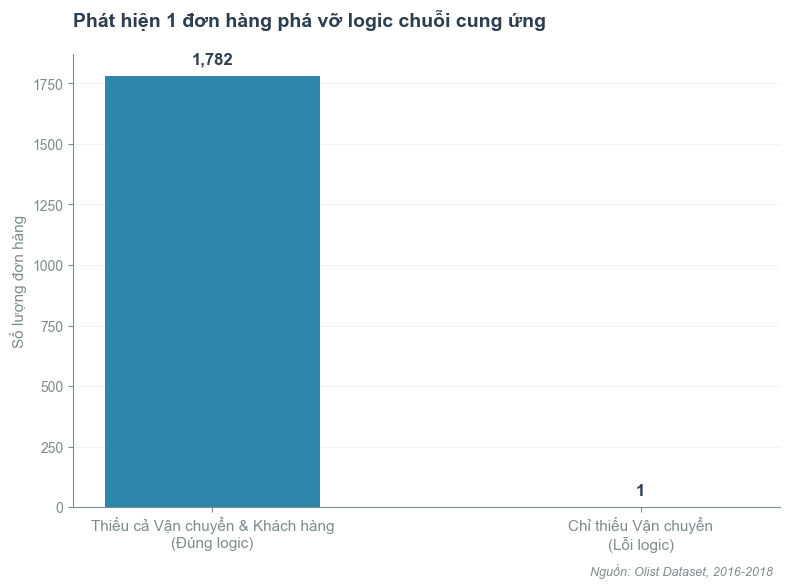

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# THIẾT LẬP STYLE THEO CHUẨN DA PROFESSIONAL
# ==========================================
COLOR_PRIMARY = '#2C3E50'
COLOR_ACCENT_POS = '#2E86AB'  # Dùng cho nhóm Đúng logic
COLOR_ACCENT_NEG = '#E63946'  # Dùng cho nhóm Lỗi logic
COLOR_NEUTRAL = '#ECF0F1'
COLOR_TEXT_GRAY = '#7F8C8D'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': COLOR_TEXT_GRAY,
    'axes.grid': True,
    'grid.color': COLOR_NEUTRAL,
    'grid.linewidth': 0.5,
    'axes.axisbelow': True,       
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ==========================================
# 1. ĐỌC VÀ XỬ LÝ DỮ LIỆU
# ==========================================
orders_file_path = '../data/raw/olist_orders_dataset.csv'
df_orders = pd.read_csv(orders_file_path)

# Lấy tập 1783 đơn hàng bị thiếu ngày giao cho đơn vị vận chuyển
missing_carrier = df_orders[df_orders['order_delivered_carrier_date'].isnull()]
total_missing_carrier = len(missing_carrier)

# Kiểm tra sự giao thoa: Đếm số lượng có/không có ngày giao khách hàng trong tập này
missing_both = missing_carrier['order_delivered_customer_date'].isnull().sum()
missing_carrier_only = total_missing_carrier - missing_both
fig, ax = plt.subplots(figsize=(8, 6))

categories = ['Thiếu cả Vận chuyển & Khách hàng\n(Đúng logic)', 'Chỉ thiếu Vận chuyển\n(Lỗi logic)']
values = [missing_both, missing_carrier_only]

colors = [COLOR_ACCENT_POS, COLOR_ACCENT_NEG]

bars = ax.bar(categories, values, color=colors, width=0.5)
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (total_missing_carrier * 0.02), 
            f'{int(yval):,}', ha='center', va='bottom', 
            fontsize=12, color=COLOR_PRIMARY, fontweight='bold')
if missing_carrier_only > 0:
    insight_title = f'Phát hiện {missing_carrier_only} đơn hàng phá vỡ logic chuỗi cung ứng'
else:
    insight_title = '100% đơn hàng thiếu ngày Vận chuyển đều khuyết ngày giao Khách hàng (Đúng logic)'

ax.set_title(insight_title, fontsize=14, fontweight='bold', color=COLOR_PRIMARY, loc='left', pad=20)

ax.set_ylabel('Số lượng đơn hàng', color=COLOR_TEXT_GRAY, fontsize=11)
ax.tick_params(axis='x', colors=COLOR_TEXT_GRAY, labelsize=11)
ax.tick_params(axis='y', colors=COLOR_TEXT_GRAY, labelsize=10)
ax.grid(axis='y', color=COLOR_NEUTRAL, linestyle='-') 
ax.grid(axis='x', visible=False) 

# Nguồn dữ liệu
ax.text(0.99, -0.15, 'Nguồn: Olist Dataset, 2016-2018', transform=ax.transAxes,
        ha='right', fontsize=9, color=COLOR_TEXT_GRAY, style='italic')

plt.tight_layout()
plt.show()

##### ==> Xem xét drop dòng bị lỗi logic 

##### *4. olist_products: 610 dòng missing lần lượt ở các cột*
* product_category_name
* product_description_length 
* product_name_lenght
* product_photos_qty

Số lượng sản phẩm bị thiếu metadata: 610
Số lượng đơn hàng bị ảnh hưởng: 1451


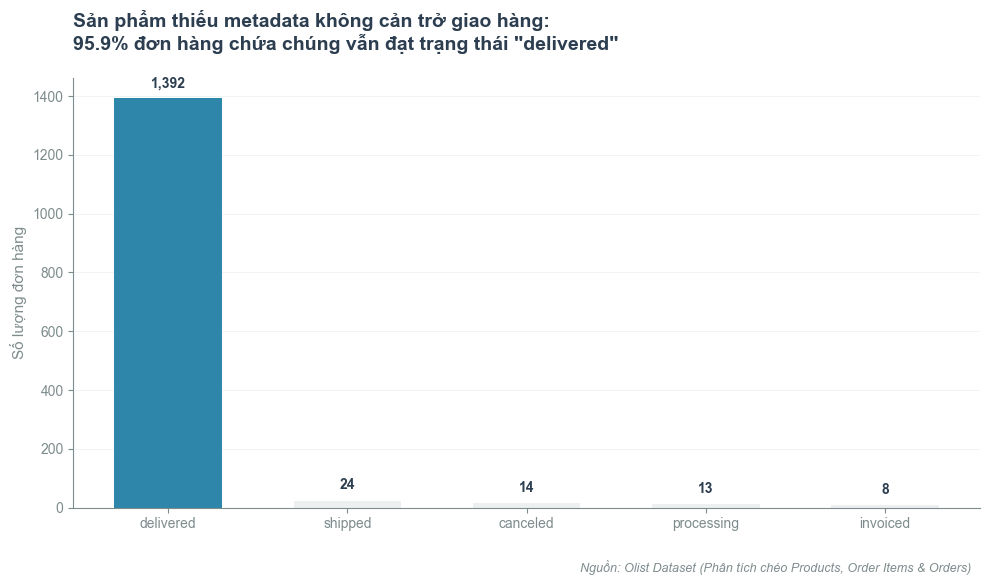

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# THIẾT LẬP STYLE THEO CHUẨN DA PROFESSIONAL
# ==========================================
COLOR_PRIMARY = '#2C3E50'
COLOR_ACCENT_POS = '#2E86AB'
COLOR_ACCENT_NEG = '#E63946'
COLOR_NEUTRAL = '#ECF0F1'
COLOR_TEXT_GRAY = '#7F8C8D'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': COLOR_TEXT_GRAY,
    'axes.grid': True,
    'grid.color': COLOR_NEUTRAL,
    'grid.linewidth': 0.5,
    'axes.axisbelow': True,       
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ==========================================
# 1. TRUY VẾT DỮ LIỆU QUA 3 BẢNG (LỌC PHỄU)
# ==========================================
# Bước 1: Tìm 610 product_id bị lỗi
products_path = '../data/raw/olist_products_dataset.csv'
df_products = pd.read_csv(products_path)

missing_cols = ['product_category_name', 'product_name_lenght', 
                'product_description_lenght', 'product_photos_qty']

# Lọc các dòng bị missing ở bất kỳ cột nào trong 4 cột trên
missing_products_mask = df_products[missing_cols].isnull().any(axis=1)
missing_product_ids = df_products[missing_products_mask]['product_id'].unique()

print(f"Số lượng sản phẩm bị thiếu metadata: {len(missing_product_ids)}")

# Bước 2: Tìm các order_id chứa các sản phẩm này
items_path = '../data/raw/olist_order_items_dataset.csv'
df_items = pd.read_csv(items_path, usecols=['order_id', 'product_id'])

# Dùng .isin() để dò tìm
affected_orders = df_items[df_items['product_id'].isin(missing_product_ids)]['order_id'].unique()

print(f"Số lượng đơn hàng bị ảnh hưởng: {len(affected_orders)}")

# Bước 3: Lấy order_status của các đơn hàng bị ảnh hưởng
orders_path = '../data/raw/olist_orders_dataset.csv'
df_orders = pd.read_csv(orders_path, usecols=['order_id', 'order_status'])

affected_orders_status = df_orders[df_orders['order_id'].isin(affected_orders)]
status_counts = affected_orders_status['order_status'].value_counts()

# ==========================================
# 2. VẼ BIỂU ĐỒ BAR CHART
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))

colors = [COLOR_NEUTRAL] * len(status_counts)
if len(colors) > 0:
    # Highlight thanh đầu tiên (nhóm chiếm đa số) bằng màu xanh Positive (vì nếu status là 'delivered' thì đó là tín hiệu tốt)
    colors[0] = COLOR_ACCENT_POS 

bars = ax.bar(status_counts.index, status_counts.values, color=colors, width=0.6)

# Thêm Data label
for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        ax.text(bar.get_x() + bar.get_width()/2, yval + (status_counts.max() * 0.02), 
                f'{int(yval):,}', ha='center', va='bottom', 
                fontsize=10, color=COLOR_PRIMARY, fontweight='bold')

# Tự động tạo Insight Title
if not status_counts.empty:
    top_status = status_counts.index[0]
    top_pct = (status_counts.values[0] / status_counts.sum()) * 100
    insight_title = f'Sản phẩm thiếu metadata không cản trở giao hàng:\n{top_pct:.1f}% đơn hàng chứa chúng vẫn đạt trạng thái "{top_status}"'
else:
    insight_title = 'Không có đơn hàng nào chứa các sản phẩm lỗi này'

ax.set_title(insight_title, fontsize=14, fontweight='bold', color=COLOR_PRIMARY, loc='left', pad=20)

ax.set_ylabel('Số lượng đơn hàng', color=COLOR_TEXT_GRAY, fontsize=11)
ax.tick_params(axis='x', colors=COLOR_TEXT_GRAY, labelsize=10)
ax.tick_params(axis='y', colors=COLOR_TEXT_GRAY, labelsize=10)

ax.grid(axis='y', color=COLOR_NEUTRAL, linestyle='-') 
ax.grid(axis='x', visible=False) 

ax.text(0.99, -0.15, 'Nguồn: Olist Dataset (Phân tích chéo Products, Order Items & Orders)', 
        transform=ax.transAxes, ha='right', fontsize=9, color=COLOR_TEXT_GRAY, style='italic')

plt.tight_layout()
plt.show()

##### ==> Các thông tin như trên không thật sự ảnh hưởng đến việc giao hàng, kiểm tra lại và ra quyết định sau

##### *2. olist_products: 2 dòng missing lần lượt ở các cột*
* product_height 
* product_length
* product_weight
* product_width

In [2]:
import pandas as pd

# 1. Tìm các product_id bị thiếu product_weight_g
products_path = '../data/raw/olist_products_dataset.csv'
df_products = pd.read_csv(products_path, usecols=['product_id', 'product_weight_g'])

# Lấy danh sách ID các sản phẩm bị thiếu cân nặng
missing_weight_mask = df_products['product_weight_g'].isnull()
missing_weight_ids = df_products[missing_weight_mask]['product_id'].unique()

# 2. Tìm xem có order_id nào chứa các sản phẩm này không
items_path = '../data/raw/olist_order_items_dataset.csv'
df_items = pd.read_csv(items_path, usecols=['order_id', 'product_id'])

# Lọc ra các order_id có dính dáng đến sản phẩm lỗi
affected_orders = df_items[df_items['product_id'].isin(missing_weight_ids)]['order_id'].unique()

# 3. Kiểm tra và trả kết quả
if len(affected_orders) == 0:
    print("✅ TÍN HIỆU TỐT: Không có đơn hàng nào chứa các sản phẩm bị thiếu cân nặng (product_weight_g).")
    print(f"Số lượng sản phẩm bị lỗi trong database là {len(missing_weight_ids)}, nhưng chúng chưa từng được bán ra.")
else:
    # Nếu có đơn hàng, tiếp tục lấy status
    orders_path = '../data/raw/olist_orders_dataset.csv'
    df_orders = pd.read_csv(orders_path, usecols=['order_id', 'order_status'])
    
    # Lọc lấy status và đếm
    affected_orders_status = df_orders[df_orders['order_id'].isin(affected_orders)]
    status_counts = affected_orders_status['order_status'].value_counts()
    
    print(f"⚠️ CẢNH BÁO: Phát hiện {len(affected_orders)} đơn hàng chứa sản phẩm bị thiếu cân nặng.")
    print("\nPhân bổ trạng thái của các đơn hàng này:")
    print("-" * 40)
    
    # In ra dạng bảng đẹp mắt trên console
    for status, count in status_counts.items():
        pct = (count / status_counts.sum()) * 100
        print(f"Trạng thái '{status}': {count} đơn ({pct:.1f}%)")

⚠️ CẢNH BÁO: Phát hiện 16 đơn hàng chứa sản phẩm bị thiếu cân nặng.

Phân bổ trạng thái của các đơn hàng này:
----------------------------------------
Trạng thái 'delivered': 16 đơn (100.0%)


##### ==> Vì chỉ có 2 sản phẩm bị thiếu thông tin về kích cỡ, cân nặng và chỉ có mặt trong 16 đơn hàng nên đang xem xét drop các dòng này (MCAR)